In [10]:
from pathlib import Path
import pickle

results_root = Path("../results/important/2000")
profiles = ["baseline", "conservative", "optimistic"]

episode_paths = {}
for profile_name in profiles:
    matches = sorted(
        results_root.glob(f"batch_env_lookahead_{profile_name}_*/episode_0042.pkl")
    )
    if not matches:
        raise FileNotFoundError(
            f"No episode_0042.pkl found for profile={profile_name!r} under {results_root}"
        )
    episode_paths[profile_name] = matches[-1]

episode_records = {}
for profile_name, results_path in episode_paths.items():
    with results_path.open("rb") as f:
        episode_records[profile_name] = pickle.load(f)

episode_paths

{'baseline': WindowsPath('../results/important/2000/batch_env_lookahead_baseline_20260609_170434/episode_0042.pkl'),
 'conservative': WindowsPath('../results/important/2000/batch_env_lookahead_conservative_20260609_170433/episode_0042.pkl'),
 'optimistic': WindowsPath('../results/important/2000/batch_env_lookahead_optimistic_20260609_170433/episode_0042.pkl')}

In [ ]:
import pandas as pd

pd.concat(
    [
        record.to_dataframe().assign(profile=profile_name)
        for profile_name, record in episode_records.items()
    ],
    ignore_index=True,
).head()

,n_electric,n_diesel,avg_age,energy_price_diesel,energy_price_electricity,purchase_price_DT,purchase_price_BET,productivity_BET,reward,revenue,diesel_cost,electricity_cost,salary_cost,interest_cost,depreciation_cost,sale_result,capex,opex,total_reward
year,,,,,,,,,,,,,,,,,,,
2026,0,8,3.500,18.000000,3.000000,1800000.0,3200000.000,0.706341,1.167730e+07,3.120000e+07,1.142638e+07,0.000000e+00,6400000.0,472320.00000,2160000.00,9.360000e+05,2632320.000,1.782638e+07,1.167730e+07
2027,0,8,3.500,18.311506,3.075382,1800000.0,2930490.000,0.709678,1.157300e+07,3.120000e+07,1.153068e+07,0.000000e+00,6400000.0,472320.00000,2160000.00,9.360000e+05,2632320.000,1.793068e+07,1.157300e+07
2028,0,8,3.500,18.478655,3.117692,1800000.0,2834792.000,0.714666,1.111752e+07,3.120000e+07,1.198616e+07,0.000000e+00,6400000.0,472320.00000,2160000.00,9.360000e+05,2632320.000,1.838616e+07,1.111752e+07
2029,0,8,3.500,19.208595,3.028731,1800000.0,2501291.500,0.721990,1.102928e+07,3.120000e+07,1.207440e+07,0.000000e+00,6400000.0,472320.00000,2160000.00,9.360000e+05,2632320.000,1.847440e+07,1.102928e+07
2030,0,8,3.500,19.350000,3.031315,1800000.0,2128530.000,0.732466,1.084160e+07,3.120000e+07,1.226208e+07,0.000000e+00,6400000.0,472320.00000,2160000.00,9.360000e+05,2632320.000,1.866208e+07,1.084160e+07
2031,0,8,3.500,19.650770,2.881642,1800000.0,1989597.375,0.746905,1.073180e+07,3.120000e+07,1.237188e+07,0.000000e+00,6400000.0,472320.00000,2160000.00,9.360000e+05,2632320.000,1.877188e+07,1.073180e+07
2032,0,8,3.500,19.826736,2.843138,1800000.0,1992840.875,0.765824,1.021851e+07,3.120000e+07,1.288517e+07,0.000000e+00,6400000.0,472320.00000,2160000.00,9.360000e+05,2632320.000,1.928517e+07,1.021851e+07
2033,0,8,3.500,20.649305,2.826295,1800000.0,2090919.125,0.789028,1.020871e+07,3.047964e+07,1.134800e+07,7.588798e+05,6400000.0,481862.15625,2218183.75,9.360000e+05,2700046.000,1.850688e+07,1.020871e+07
2034,1,7,3.500,20.783882,2.864023,1800000.0,2123082.250,0.815292,1.027065e+07,2.997109e+07,9.940040e+06,1.521140e+06,6400000.0,492459.25000,2282800.25,9.360000e+05,2775259.500,1.786118e+07,1.027065e+07


In [12]:
from importlib import reload

import plot_helpers

reload(plot_helpers)
from plot_helpers import plot_episode_fleet_composition

Profile: baseline


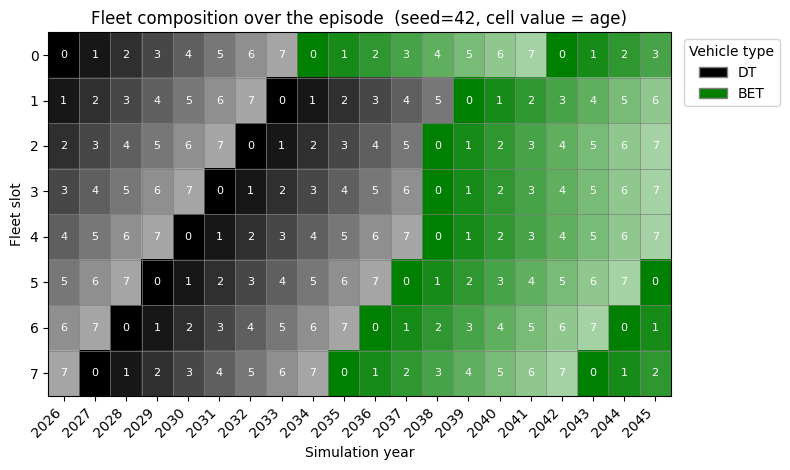

Profile: conservative


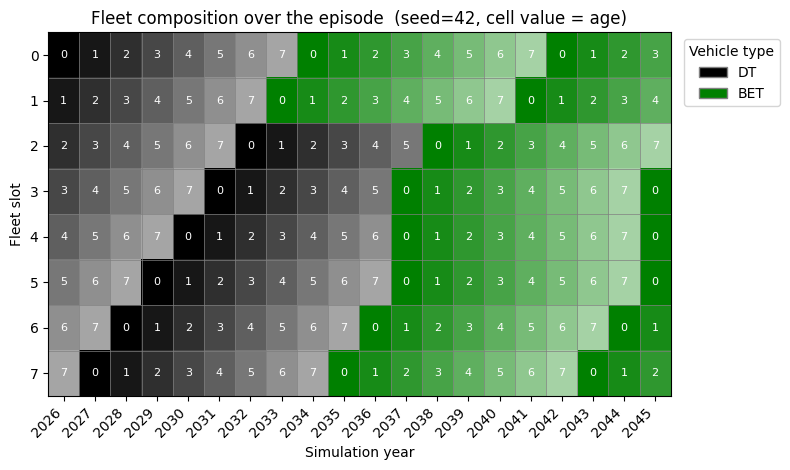

Profile: optimistic


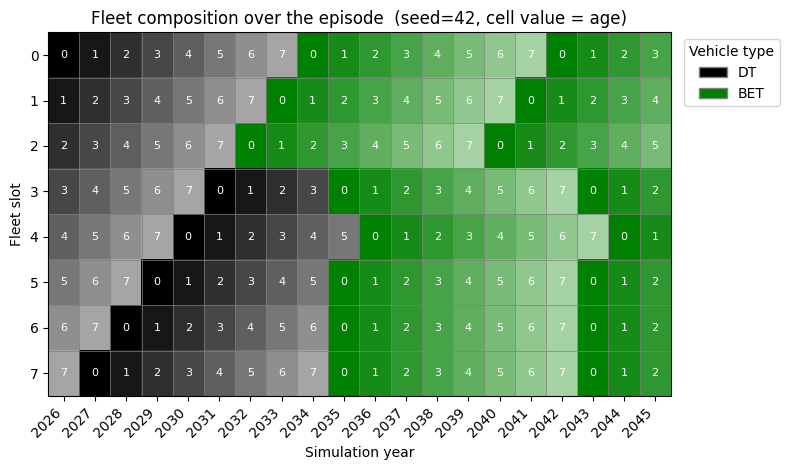

In [13]:
for profile_name, record in episode_records.items():
    print(f"Profile: {profile_name}")
    plot_episode_fleet_composition(record)